In [100]:
import requests
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from scipy.interpolate import PchipInterpolator

# Question: Will BTC hit 100000 by 31DEC26?

target_expiry_str = "25DEC26"
target_expiry = datetime.strptime(target_expiry_str, "%d%b%y").strftime("%Y%m%d")
required_strike = 100000.0

print("target_expiry:", target_expiry)

target_expiry: 20261225


In [123]:
class BTCOptionSurface:
    def __init__(self, target_expiry_str):
        self.target_expiry_str = target_expiry_str

    def get_overall_smile(self, dr_options_df, okx_options_df, bybit_options_df):
        all_options = pd.concat([dr_options_df, okx_options_df, bybit_options_df], ignore_index=True)

        curve = all_options.groupby("strike").apply(
            lambda x: np.average(x.mark_iv, weights=x.open_interest_notional)).reset_index()

        curve.columns = ["strike", "mark_iv"]

        self.curve = curve

    def get_weighted_spot(self, dr, bybit, okx):
        spots = [dr.spot, bybit.spot, okx.spot]
        weights = [dr.volume, bybit.volume, okx.volume]

        self.weighted_spot = np.average(spots, weights=weights)

        print("weighted spot:", self.weighted_spot)

    def plot_smile(self, options_df, exchange):

        plt.plot(options_df.strike,
                options_df.mark_iv * 100,   # convert decimal IV to %
                marker="o"
            )
        
        plt.xlabel("Strike")
        plt.ylabel("Implied Volatility (%)")
        plt.title(f"{exchange} BTC {self.target_expiry_str} IV Smile")
        plt.grid(True)

        plt.show()

    def interpolate_iv(self, options_df, required_strike):
        # Question: Will BTC hit 100000 by 31DEC26?

        # It prevents wild overshoots and spurious oscillations found in standard cubic splines, 
        # making it ideal for monotonic data, bounded physical measurements, and financial curves
        f = PchipInterpolator(options_df.strike, options_df.mark_iv)

        iv = float(f(required_strike))

        print(f'BTC {required_strike} strike iv: {iv}')

    def prob_finish_above(self, spot, strike, iv, T, r=0):

        d2 = (np.log(spot / strike) + (r - 0.5 * iv ** 2) * T) / (iv * np.sqrt(T))

        return norm.cdf(d2)

    def prob_touch(self, spot, strike, iv, T, r=0, paths=100000, time_steps=365):

        dt = T / time_steps
        Z = np.random.normal(0, 1, size=(paths, time_steps))

        daily_return = ((r - 0.5 * iv ** 2) * dt + iv * np.sqrt(dt) * Z)

        prices = spot * np.exp(np.cumsum(daily_return, axis=1))

        hit = prices.max(axis=1) >= strike

        p_touch = hit.mean()

        print(p_touch)

surface = BTCOptionSurface(target_expiry_str)

In [111]:
class Deribit:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": "BTC_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        self.spot = float(data["last_price"])
        self.volume = float(data["stats"]["volume"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):
        
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        deribit_instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": "BTC",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        deribit_quotes_df = pd.DataFrame(quotes)

        deribit_df = deribit_instruments_df.merge(deribit_quotes_df, on="instrument_name", how="left")
        deribit_df["open_interest_notional"] = deribit_df["open_interest"] * deribit_df["contract_size"]
        deribit_df["mark_iv"] = deribit_df["mark_iv"].astype(float) / 100
        parts = deribit_df["instrument_name"].str.split("-")
        deribit_df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")

        self.deribit_df = deribit_df

    def get_smile(self, target_expiry):

        self.options_df = self.deribit_df[
            (self.deribit_df["expiry"] == target_expiry) &
            (self.deribit_df["option_type"] == "call") &
            (self.deribit_df["open_interest_notional"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

dr = Deribit(target_expiry=target_expiry)
dr.options_df.head()

spot: 64353.0 volume24h: 11.6228


,state,price_index,kind,instrument_name,instrument_type,maker_commission,taker_commission,underlying_type,instrument_id,expiration_timestamp,...,mark_iv,underlying_price,underlying_index,base_currency_y,quote_currency_y,estimated_delivery_price,volume_usd,mid_price,open_interest_notional,expiry
538,open,btc_usd,option,BTC-25DEC26-30000-C,reversed,0.0003,0.0003,crypto,587781,1798185600000,...,0.6994,65387.69,BTC-25DEC26,BTC,BTC,64286.01,55616.06,0.54550,291.0,20261225
540,open,btc_usd,option,BTC-25DEC26-35000-C,reversed,0.0003,0.0003,crypto,573922,1798185600000,...,0.6249,65387.69,BTC-25DEC26,BTC,BTC,64286.01,0.00,0.47125,77.7,20261225
542,open,btc_usd,option,BTC-25DEC26-40000-C,reversed,0.0003,0.0003,crypto,568999,1798185600000,...,0.5658,65387.69,BTC-25DEC26,BTC,BTC,64286.01,0.00,0.39850,250.9,20261225
544,open,btc_usd,option,BTC-25DEC26-45000-C,reversed,0.0003,0.0003,crypto,573924,1798185600000,...,0.5101,65387.69,BTC-25DEC26,BTC,BTC,64286.01,0.00,0.32725,54.3,20261225
546,open,btc_usd,option,BTC-25DEC26-50000-C,reversed,0.0003,0.0003,crypto,569001,1798185600000,...,0.4637,65387.69,BTC-25DEC26,BTC,BTC,64286.01,0.00,0.25925,260.8,20261225


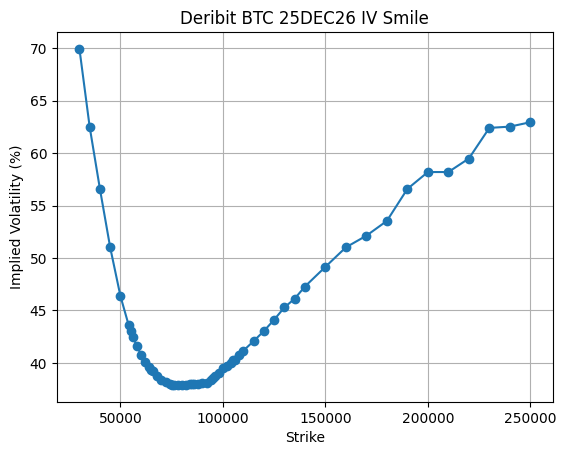

In [119]:
surface.plot_smile(options_df=dr.options_df, exchange="Deribit")

In [113]:
class OKX:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://www.okx.com/api/v5/market/ticker"
        params = {"instId": "BTC-USDT"}

        data = requests.get(url=url, params=params).json()["data"][0]

        self.spot = float(data["last"])
        self.volume = float(data["vol24h"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):

        url = "https://www.okx.com/api/v5/public/instruments?instType=OPTION&uly=BTC-USD"
        data = requests.get(url).json()
        contract_size = float(data["data"][0]["ctVal"])
        
        url = "https://www.okx.com/api/v5/public/open-interest"
        params = {
            "instType": "OPTION",
            "uly": "BTC-USD"
        }

        oi = requests.get(url=url, params=params).json()["data"]
        oi_df = pd.DataFrame(oi)
        oi_df = oi_df.rename(columns={"oi": "open_interest"})
        oi_df["open_interest"] = oi_df["open_interest"].astype(float)
        oi_df["open_interest_notional"] = oi_df["open_interest"] * contract_size

        url = "https://www.okx.com/api/v5/public/opt-summary"
        params = {"uly": "BTC-USD"}

        summary = requests.get(url=url, params=params).json()["data"]
        summary_df = pd.DataFrame(summary)
        summary_df = summary_df.rename(columns={"markVol": "mark_iv"})
        summary_df["mark_iv"] = summary_df["mark_iv"].astype(float)

        parts = summary_df["instId"].str.split("-")

        summary_df["ccy"] = parts.str[1]
        summary_df["strike"] = parts.str[3].astype(float)
        summary_df["expiry"] = pd.to_datetime(parts.str[2], format="%y%m%d").dt.strftime("%Y%m%d")
        summary_df["option_type"] = parts.str[4].map({"C": "call", "P": "put"})

        self.okx_df = summary_df.merge(oi_df, on="instId", how="left")

    def get_smile(self, target_expiry):

        self.options_df = self.okx_df[
            (self.okx_df["ccy"] == "USD") &
            (self.okx_df["expiry"] == target_expiry) &
            (self.okx_df["option_type"] == "call") &
            (self.okx_df["open_interest_notional"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

okx = OKX(target_expiry=target_expiry)
okx.options_df.head()

spot: 64323.1 volume24h: 5828.65157684


,askVol,bidVol,buyApr,delta,deltaBS,distance,fwdPx,gamma,gammaBS,instId,...,ccy,strike,expiry,option_type,instType_y,open_interest,oiCcy,oiUsd,ts_y,open_interest_notional
575,0.7653893286132812,0.6848230834960938,,0.43283939932099047,0.9769912217957343,-0.54106626,65368.91398835040238,-0.7463973293892224,0.000001856133806377479,BTC-USD-261225-30000-C,...,USD,30000.0,20261225,call,OPTION,4075.0,40.75,2620506.175,1785910479915,4075.0
568,0.675057478027344,0.6189052465820313,,0.4936380566783,0.9635717905238507,-0.46457731,65368.91398835040238,-0.7875234056665715,0.0000031083432823353345,BTC-USD-261225-35000-C,...,USD,35000.0,20261225,call,OPTION,150.0,1.5,96460.35,1785910479915,150.0
552,0.5288785711669921,0.4998869299316406,,0.5837307962233705,0.9095195848376931,-0.31159939,65368.91398835040238,-0.654694994931804,0.000007979138942460826,BTC-USD-261225-45000-C,...,USD,45000.0,20261225,call,OPTION,163.0,1.63,104820.247,1785910479915,163.0
549,0.4766936169433594,0.4553313549804688,,0.5990609114052445,0.8573987156325892,-0.23511044,65368.91398835040238,-0.4212939119895364,0.000012088185667439826,BTC-USD-261225-50000-C,...,USD,50000.0,20261225,call,OPTION,510.0,5.1,327965.19,1785910479915,510.0
576,0.461129683227539,0.4422088226318359,,0.5969683878124763,0.8298002840670735,-0.20451486,65368.91398835040238,-0.29289232312195046,0.000014021113923368543,BTC-USD-261225-52000-C,...,USD,52000.0,20261225,call,OPTION,50.0,0.5,32153.45,1785910479915,50.0


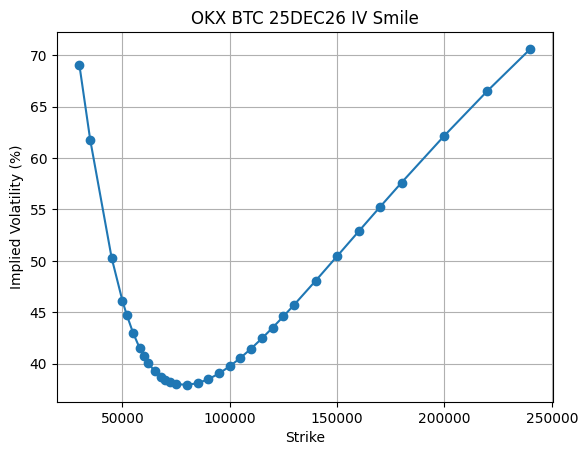

In [120]:
surface.plot_smile(options_df=okx.options_df, exchange="OKX")

In [115]:
class Bybit:
    def __init__(self, target_expiry):
         self.get_spot()
         self.get_df()
         self.get_smile(target_expiry)

    def get_spot(self):
        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "category": "spot",
            "symbol": "BTCUSDT"
        }

        data = requests.get(url=url, params=params).json()["result"]["list"][0]
        
        self.spot = float(data["lastPrice"])
        self.volume = float(data["volume24h"])
        print("spot:", self.spot, "volume24h:", self.volume)

    def get_df(self):
        contract_size = 1.0

        url = "https://api.bybit.com/v5/market/tickers"
        params = {
            "baseCoin": "BTC",
            "category": "option"
        }

        bybit_data = requests.get(url=url, params=params).json()["result"]["list"]
        bybit_df = pd.DataFrame(bybit_data)
        bybit_df = bybit_df.rename(columns={"markIv": "mark_iv", 
                                            "openInterest": "open_interest"})

        bybit_df["open_interest"] = bybit_df["open_interest"].astype(float)
        bybit_df["open_interest_notional"] = bybit_df["open_interest"] * contract_size
        bybit_df["mark_iv"] = bybit_df["mark_iv"].astype(float)

        parts = bybit_df["symbol"].str.split("-")
        bybit_df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        bybit_df["strike"] = parts.str[2].astype(float)
        bybit_df["option_type"] = parts.str[3].map({"C": "call", "P": "put"})

        self.bybit_df = bybit_df

    def get_smile(self, target_expiry):

        self.options_df = self.bybit_df[
            (self.bybit_df["expiry"] == target_expiry) &
            (self.bybit_df["option_type"] == "call") &
            (self.bybit_df["open_interest_notional"] >= 10)
        ]

        self.options_df = self.options_df.sort_values("strike")

bybit = Bybit(target_expiry=target_expiry)
bybit.options_df.head()

spot: 64316.1 volume24h: 6562.108608


,symbol,bid1Price,bid1Size,bid1Iv,ask1Price,ask1Size,ask1Iv,lastPrice,highPrice24h,lowPrice24h,...,delta,gamma,vega,theta,predictedDeliveryPrice,change24h,open_interest_notional,expiry,strike,option_type
448,BTC-25DEC26-70000-C-USDT,4375,3.52,0.3813,4445,1,0.3856,4210,4210,4210,...,0.43489322,0.00002518,160.64111775,-21.66048919,0,0,20.70,20261225,70000.0,call
453,BTC-25DEC26-75000-C-USDT,2865,3.74,0.3777,2895,8.5,0.3798,2700,2700,2700,...,0.32193638,0.00002326,146.31368778,-19.45423773,0,0,14.95,20261225,75000.0,call
415,BTC-25DEC26-80000-C-USDT,1840,5.74,0.3766,1855,7.57,0.3778,1795,1820,1675,...,0.23000211,0.00001975,123.92382679,-16.43079381,0,0,33.64,20261225,80000.0,call
428,BTC-25DEC26-85000-C-USDT,1180,6.17,0.3783,1195,14.83,0.3798,1150,1155,1090,...,0.1611389,0.00001581,99.76019272,-13.30230314,0,0.01321586,17.38,20261225,85000.0,call
430,BTC-25DEC26-90000-C-USDT,755,3.17,0.381,780,10,0.3842,755,755,755,...,0.11222695,0.0000122,77.84941877,-10.50086804,0,0,18.43,20261225,90000.0,call


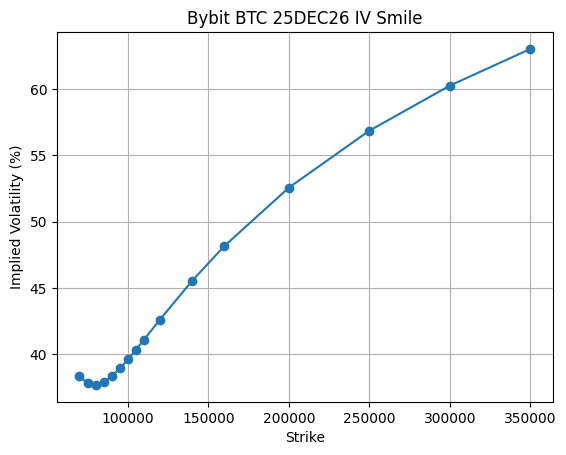

In [121]:
surface.plot_smile(options_df=bybit.options_df, exchange="Bybit")

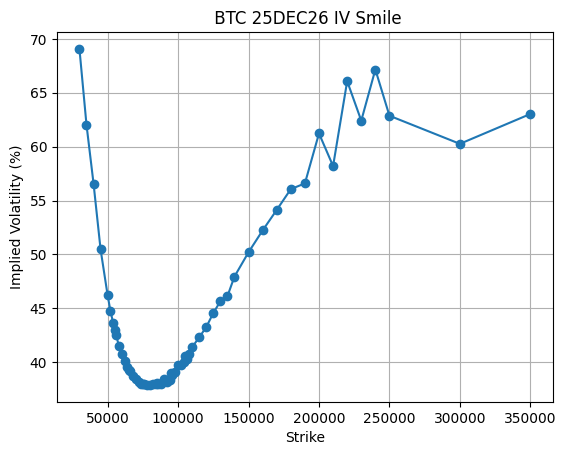

weighted spot: 64319.424316174416


In [124]:
surface.get_overall_smile(dr.options_df, okx.options_df, bybit.options_df)
surface.plot_smile(options_df=surface.curve, exchange="")
surface.get_weighted_spot(dr, okx, bybit)

In [ ]:
def prob_finish_above(spot, strike, iv, T, r=0):

    sigma = iv / 100

    d2 = (
        np.log(spot/strike)
        + (r - 0.5*sigma**2)*T
    ) / (sigma*np.sqrt(T))

    return norm.cdf(d2)


today = datetime.now(timezone.utc)
expiry = datetime(2026, 12, 25, tzinfo=timezone.utc)

spot = 64434

T = (expiry - today).days / 365

p = prob_finish_above(spot=spot, strike=required_strike, iv=iv, T=T, r=0)

print(p)

In [ ]:
def prob_touch(spot, strike, iv, T, r=0, paths=100000, time_steps=365):

    dt = T / time_steps
    Z = np.random.normal(0, 1, size=(paths, time_steps))

    daily_return = ((r - 0.5 * iv ** 2) * dt + iv * np.sqrt(dt) * Z)

    prices = spot * np.exp(np.cumsum(daily_return, axis=1))

    hit = prices.max(axis=1) >= strike

    p_touch = hit.mean()

    print(p_touch)

prob_touch(spot=spot, strike=required_strike, iv=iv, T=T, r=0)

for paths in [10000, 50000, 100000, 500000]:
    prob_touch(spot=spot, strike=required_strike, iv=iv, T=T, paths=paths)

In [ ]:
# Keep trading journal

# Your thesis.
# Why you think the market is mispriced.
# Position size.
# Exit criteria.
# What actually happened.

In [ ]:
class Deribit:
    def __init__(self, currencies, target_expiry):
         self.data = {}

         for currency in currencies:
            spot, volume = self.get_spot(currency)
            df = self.get_df(currency)
            curve_df = self.get_curve_df(df, target_expiry)

            self.data[currency] = {
                "spot": spot,
                "volume": volume,
                "df": df,
                "curve_df": curve_df
            }

    def get_spot(self, currency):
        url = "https://www.deribit.com/api/v2/public/ticker"
        params = {"instrument_name": f"{currency}_USDT"}

        data = requests.get(url, params=params).json()["result"]
        
        spot = float(data["last_price"])
        volume = float(data["stats"]["volume"])

        print("spot:", spot, "volume24h:", volume)

        return spot, volume

    def get_df(self, currency):
        
        url = "https://www.deribit.com/api/v2/public/get_instruments"
        params = {
            "currency": f"{currency}",
            "kind": "option"
        }

        instruments = requests.get(url=url, params=params).json()["result"]
        instruments_df = pd.DataFrame(instruments)

        url = "https://www.deribit.com/api/v2/public/get_book_summary_by_currency"
        params = {
            "currency": f"{currency}",
            "kind": "option"
        }

        quotes = requests.get(url=url, params=params).json()["result"]
        quotes_df = pd.DataFrame(quotes)

        df = instruments_df.merge(quotes_df, on="instrument_name", how="left")
        df["open_interest_notional"] = df["open_interest"] * df["contract_size"]
        df["mark_iv"] = df["mark_iv"].astype(float) / 100

        parts = df["instrument_name"].str.split("-")

        df["expiry"] = pd.to_datetime(parts.str[1], format="%d%b%y").dt.strftime("%Y%m%d")
        df["expiry_dt"] = pd.to_datetime(parts.str[1], format="%d%b%y", utc=True)
        df["T"] = (df["expiry_dt"] - datetime.now(timezone.utc)).dt.total_seconds() / (365.25 * 24 * 3600)
        df["total_variance"] = df["mark_iv"] ** 2 * df["T"]

        df = df[df["open_interest_notional"] >= 10]
        df = df.sort_values(["expiry", "strike"])

        return df

    def get_curve_df(self, df, target_expiry):

        curve_df = df[
            (df["expiry"] == target_expiry) &
            (df["option_type"] == "call")
        ]

        curve_df = curve_df.sort_values("strike")

        return curve_df

deribit = Deribit(currencies=["BTC", "ETH"], target_expiry=target_expiry)